In [12]:
%cd ..

!pip install -e .

/Users/rsalik/Documents


/Users/rsalik/.pyenv/versions/3.13.1/lib/python3.13/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Obtaining file:///Users/rsalik/Documents
ERROR: file:///Users/rsalik/Documents does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.


In [2]:
%load_ext autoreload
%autoreload 1

import jax

from deluca.agents.new.linear import LinearAgent
from deluca.envs.gymnasium.gym import GymEnv
from deluca.filters.spectral import SpectralFilter
from deluca.learners.memory import Memory
from deluca.agents.new.linear import DefaultSettings as LinearAgentDefaultSettings
from deluca.utils.printing import Task

# JAX random key
rng = jax.random.key(0)

### **Creating an Environment**

In [3]:
%autoreload 1

import jax

from deluca.envs._brax import BraxEnv

# Creating the environment
rng, env_rng = jax.random.split(rng)
env = BraxEnv(env_rng, "inverted_double_pendulum")

/Users/rsalik/.pyenv/versions/3.13.1/envs/deluca-env/lib/python3.13/site-packages/brax/io/mjcf.py:480: UserWarning: Brax System, piplines and environments are not actively being maintained. Please see MJX for a well maintained JAX-based physics engine: https://github.com/google-deepmind/mujoco/tree/main/mjx. For a host of environments that use MJX, see: https://github.com/google-deepmind/mujoco_playground.
  warnings.warn(


#### **Defining a loss function**

In [4]:
from jax import Array
from typing import Any
import jax.numpy as jnp


def loss_fn(action: Array, next_state: Any, next_obs: Array) -> Array:
    obs = next_state.obs
    # obs[0:2] = hand position
    # obs[2:4] = target position
    hand_pos = obs[0:2]
    target_pos = obs[2:4]

    # Distance between hand and goal
    dist = jnp.linalg.norm(hand_pos - target_pos)

    # Control cost: penalize large actions
    control_cost = 0.05 * jnp.sum(jnp.square(action))

    # Convert reward into loss
    return dist + control_cost

### **Setting up an Agent**
1. Create a memory -- lets the agent store the history of observations and actions, and can add Spectral Filtering
2. Define the agent's settings, or use default
3. Create the agent itself

In [5]:
%autoreload 1

# 1. Create a memory
filter = SpectralFilter(env.observation_size, env.action_size)
memory = Memory(1, env.observation_size, env.action_size, filter=filter)

# 2. Define the agent's settings, or use default
settings = LinearAgentDefaultSettings.replace(learning_rate=1e-3, loss_fn=loss_fn) # type: ignore

# 3. Create the agent itself
rng, agent_rng = jax.random.split(rng)
agent = LinearAgent(memory, settings, rng=agent_rng)

### **Create a Training Loop**

In [6]:
%autoreload 1

rng, env_rng = jax.random.split(rng)
t, state, obs = env.reset(env_rng)

losses = []
states = [state]

N = 1000

with Task("Training agent", N) as task:
    for rng in jax.random.split(rng, N):
        arng, erng = jax.random.split(rng)
        
        loss, (new_t, new_state, new_obs), action = agent.step_and_update(env, t, state, memory.get_history(), arng)
        
        if (new_t == 0):
            memory.reset() # Episode reset

        states.append(new_state)

        memory.store(obs, action)

        losses.append(loss)

        t, state, obs = new_t, new_state, new_obs

        task.update(text=f"Loss: {loss:.4f}")


⠙ Training agent [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] [0/1000]
⠹ Training agent [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] [0/1000]
⠸ Training agent [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] [0/1000]
⠼ Training agent [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] [0/1000]
⠴ Training agent [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] [0/1000]
⠦ Training agent [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] [0/1000]
⠧ Training agent [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] [0/1000]
⠇ Training agent [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] [0/1000]
⠏ Training agent [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] [0/1000]
⠋ Training agent [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] [0/1000]
⠙ Training agent [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] [0/1000]
⠹ Training agent [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] [0/1000]
⠸ Training agent [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] [0/1000]
⠼ Training agent [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] [0/1000]
⠴ Training agent [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] [0/1000]
⠦ Training agent [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] [0/1000]
⠧ Training agent [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] [0/100

#### Plotting Results

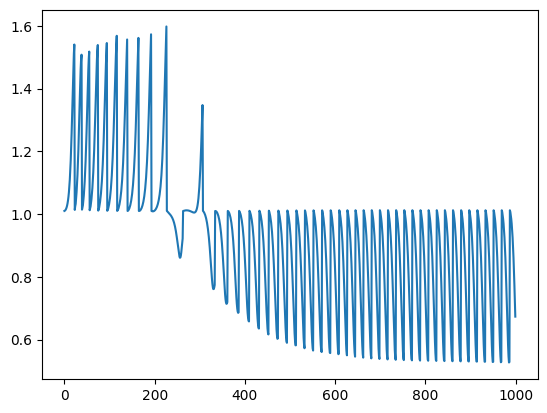

In [7]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.show()

**#### Rendering the trajectory**


**Note:** Only Brax environments support rendering. The process for displaying the render is different in Jupyter notebooks than Python scripts.

In [23]:
%autoreload 1

from IPython.display import display

display(env.render(states))

hehe
